In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
pd.set_option("display.max_columns", None)

In [6]:
sns.set_style("whitegrid")

In [7]:
df = pd.read_csv("german_credit_data.csv")

In [8]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [11]:
df ["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [12]:
df.shape

(1000, 11)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
 10  Risk              1000 non-null   str  
dtypes: int64(5), str(6)
memory usage: 86.1 KB


In [14]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
df["Job"].unique()

array([2, 1, 3, 0])

In [16]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.dropna().reset_index(drop=True)

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [19]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

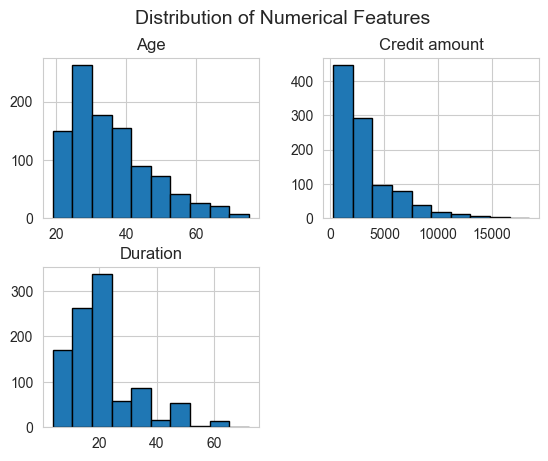

In [23]:
df[["Age", "Credit amount", "Duration"]].hist(bins=10, edgecolor="black")
plt.suptitle("Distribution of Numerical Features", fontsize=14)
plt.show()

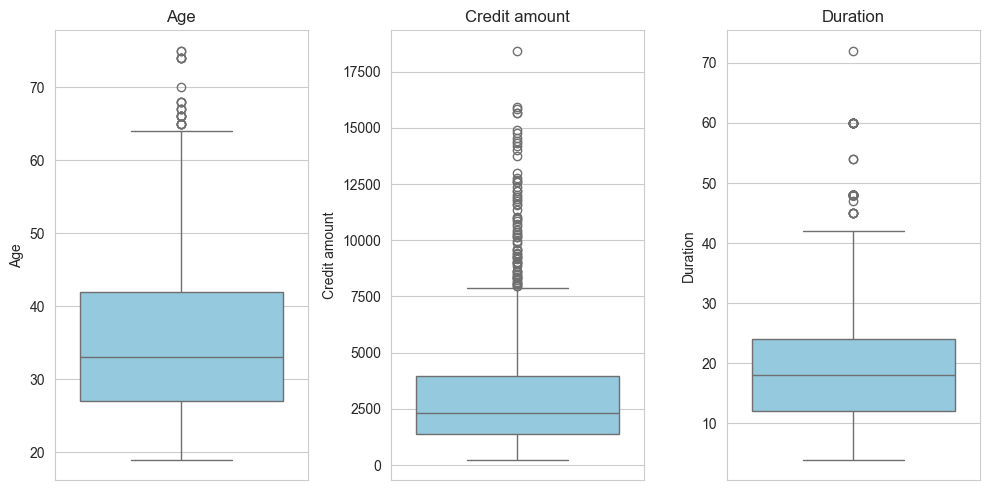

In [30]:
plt.figure(figsize=(10,5))
for i, col in enumerate (["Age", "Credit amount", "Duration"]):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(col)
    
plt.tight_layout()
plt.show()

In [32]:
df.query("Duration >= 60")

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
29,29,63,male,2,own,little,little,6836,60,business,bad
134,134,21,female,2,own,moderate,NaN,10144,60,radio/TV,good
255,255,27,male,1,own,NaN,moderate,7418,60,radio/TV,good
332,332,24,female,3,own,moderate,moderate,7408,60,car,bad
373,373,63,male,3,free,NaN,NaN,13756,60,car,good
374,374,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
616,616,27,male,3,free,NaN,moderate,9157,60,radio/TV,good
637,637,21,male,2,own,little,NaN,15653,60,radio/TV,good
672,672,42,male,3,own,little,NaN,10366,60,car,good
677,677,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad


In [33]:
categorical_cols = ["Sex", "Job", "Housing", "Saving accounts", "Checking account", "Purpose"]

/var/folders/w7/v53zky0j4y36tf6d9jfpnz3m0000gn/T/ipykernel_54772/1427411716.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette = "Set2", order = df[col].value_counts().index)
/var/folders/w7/v53zky0j4y36tf6d9jfpnz3m0000gn/T/ipykernel_54772/1427411716.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette = "Set2", order = df[col].value_counts().index)
/var/folders/w7/v53zky0j4y36tf6d9jfpnz3m0000gn/T/ipykernel_54772/1427411716.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=co

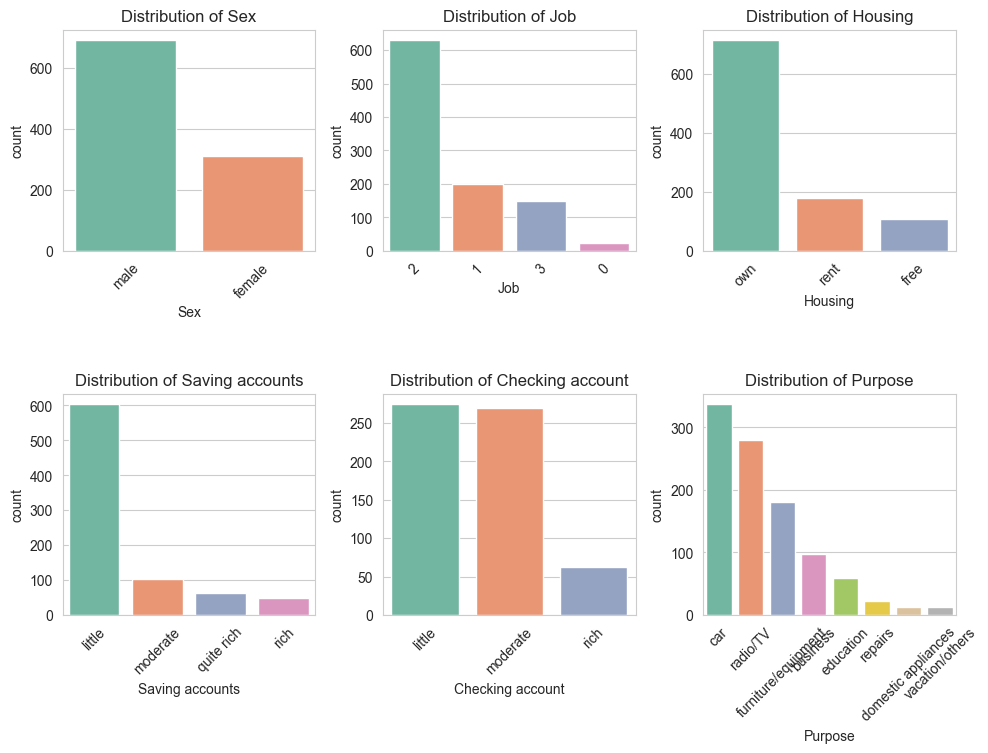

In [38]:
plt.figure(figsize=(10,10))
for i, col in enumerate(categorical_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(data=df, x=col, palette = "Set2", order = df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    
plt.tight_layout()
plt.show()

In [39]:
corr = df[["Age", "Job", "Credit amount", "Duration"]].corr()

In [40]:
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.015673,0.032716,-0.036136
Job,0.015673,1.000000,0.285385,0.210910
Credit amount,0.032716,0.285385,1.000000,0.624984
Duration,-0.036136,0.210910,0.624984,1.000000


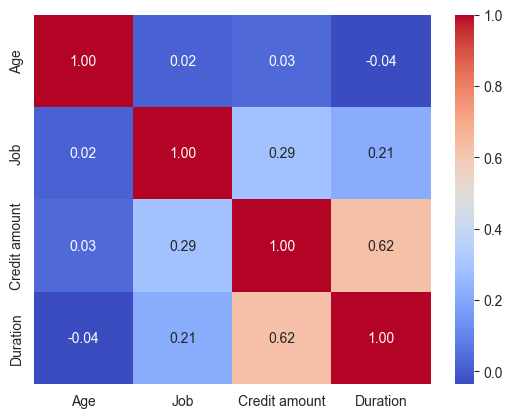

In [42]:
sns.heatmap(corr, annot= True, cmap="coolwarm", fmt=".2f")
plt.show()

/var/folders/w7/v53zky0j4y36tf6d9jfpnz3m0000gn/T/ipykernel_54772/758115397.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = "Risk", y = col, palette="Pastel2")
/var/folders/w7/v53zky0j4y36tf6d9jfpnz3m0000gn/T/ipykernel_54772/758115397.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = "Risk", y = col, palette="Pastel2")
/var/folders/w7/v53zky0j4y36tf6d9jfpnz3m0000gn/T/ipykernel_54772/758115397.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = "Risk", y = col, palette="Pastel2")


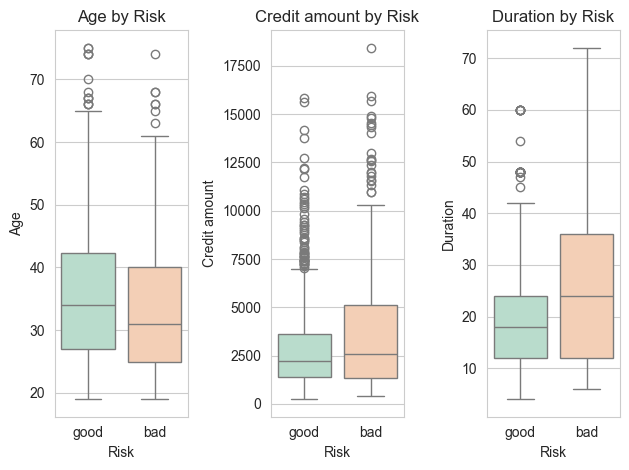

In [45]:
for i, col in enumerate (["Age", "Credit amount", "Duration"]):
    plt.subplot(1, 3, i+1)
    sns.boxplot(data = df, x = "Risk", y = col, palette="Pastel2")
    plt.title(f"{col} by Risk")
    
plt.tight_layout()
plt.show()

In [46]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [47]:
features = ["Age", "Sex", "Job", "Housing", "Saving accounts", "Checking account", "Credit amount", "Duration"]

In [48]:
target = "Risk"

In [49]:
df_model = df[features + [target]].copy()

In [51]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,67,male,2,own,NaN,little,1169,6,good
1,22,female,2,own,little,moderate,5951,48,bad
2,49,male,1,own,little,NaN,2096,12,good
3,45,male,2,free,little,little,7882,42,good
4,53,male,2,free,little,little,4870,24,bad


In [80]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [58]:
cat_cols = df_model.select_dtypes(include = "object").columns.drop("Risk")

/var/folders/w7/v53zky0j4y36tf6d9jfpnz3m0000gn/T/ipykernel_54772/710169248.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_model.select_dtypes(include = "object").columns.drop("Risk")


In [59]:
le_dict = {}

In [60]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='str')

In [61]:
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] =le
    joblib.dump(le, f"{col}_encoder.pkl")

In [62]:
le_target = LabelEncoder()

In [63]:
target

'Risk'

In [64]:
df_model[target] = le_target.fit_transform(df_model[target])

In [67]:
df_model[target].value_counts()

Risk
1    700
0    300
Name: count, dtype: int64

In [68]:
joblib.dump(le_target, "target_encoder.pkl")

['target_encoder.pkl']

In [69]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,67,1,2,1,4,0,1169,6,1
1,22,0,2,1,0,1,5951,48,0
2,49,1,1,1,0,3,2096,12,1
3,45,1,2,0,0,0,7882,42,1
4,53,1,2,0,0,0,4870,24,0


In [70]:
from sklearn.model_selection import train_test_split

In [71]:
X = df_model.drop(target, axis = 1)

In [72]:
y = df_model[target]

In [73]:
X

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration
0,67,1,2,1,4,0,1169,6
1,22,0,2,1,0,1,5951,48
2,49,1,1,1,0,3,2096,12
3,45,1,2,0,0,0,7882,42
4,53,1,2,0,0,0,4870,24
...,...,...,...,...,...,...,...,...
995,31,0,1,1,0,3,1736,12
996,40,1,3,1,0,0,3857,30
997,38,1,2,1,0,3,804,12
998,23,1,2,0,0,0,1845,45


In [75]:
y

0      1
1      0
2      1
3      1
4      0
      ..
995    1
996    1
997    1
998    0
999    1
Name: Risk, Length: 1000, dtype: int64

In [76]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

In [77]:
X_train.shape

(800, 8)

In [78]:
X_test.shape

(200, 8)

In [82]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [85]:
def train_model(model, param_grid, X_train, y_train, X_test, y_test):
    grid = GridSearchCV(model, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return best_model, acc, grid.best_params_

In [86]:
dt = DecisionTreeClassifier(random_state= 1, class_weight="balanced")
dt_param_grid = {
    "max_depth" : [3,5,7,10, None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

In [88]:
best_dt, acc_dt, params_dt = train_model(dt, dt_param_grid, X_train, y_train, X_test, y_test)

In [89]:
print("Decision Tree Accuracy", acc_dt)

Decision Tree Accuracy 0.705


In [90]:
print("Best parameters", params_dt)

Best parameters {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [92]:
rf = RandomForestClassifier(random_state=1, class_weight="balanced", n_jobs=-1)

In [93]:
rf_param_grid = {
    "n_estimators": [100,200],
    "max_depth": [5,7,10,None],
    "min_samples_split" : [2,5,10],
    "min_samples_leaf": [1,2,4]
}

In [94]:
best_rf, acc_rf, params_rf = train_model(rf, rf_param_grid, X_train, y_train, X_test, y_test)

In [95]:
print("Random Forest Accuracy", acc_rf)

Random Forest Accuracy 0.77


In [96]:
print("Best params", params_rf)

Best params {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [97]:
et = ExtraTreesClassifier(random_state=1, class_weight="balanced", n_jobs=-1)

In [98]:
et_param_grid = {
    "n_estimators": [100,200],
    "max_depth": [5,7,10,None],
    "min_samples_split" : [2,5,10],
    "min_samples_leaf": [1,2,4]
}

In [99]:
best_et, acc_et, params_et = train_model(et, et_param_grid, X_train, y_train, X_test, y_test)

In [101]:
print("Extra trees accuracy", acc_et)

Extra trees accuracy 0.745


In [102]:
print("Best params", params_et)

Best params {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [103]:
xgb = XGBClassifier(random_state=1, scale_pos_weight=(y_train==0).sum() / (y_train ==1).sum(), use_label_encoder=False, eval_metric="logloss")

In [104]:
xgb_param_grid = {
    "n_estimators" : [100, 200],
    "max_depth" : [3,5,7],
    "learning_rate": [0.01,0.1,0.2],
    "subsample": [0.7,1],
    "colsample_bytree": [0.7,1]
}

In [105]:
best_xgb, acc_xgb, params_xgb = train_model(xgb, xgb_param_grid, X_train, y_train, X_test, y_test)

/Users/mahnurimran/Desktop/Credit Risk Model/.venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [17:50:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/mahnurimran/Desktop/Credit Risk Model/.venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [17:50:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/mahnurimran/Desktop/Credit Risk Model/.venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [17:50:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/mahnurimran/Desktop/Credit Risk Model/.venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [17:50:31] WARN

In [106]:
print("XGB accuracy", acc_xgb)

XGB accuracy 0.735


In [107]:
print("Best params", params_xgb)

Best params {'colsample_bytree': 0.7, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1}


In [108]:
best_et.predict(X_test)

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 0])

In [109]:
joblib.dump(best_et, "extra_trees_credit_model.pkl")

['extra_trees_credit_model.pkl']